In [1]:
#Import libraries 
import pandas as pd
import numpy as np
import requests
import matplotlib as plt
import seaborn as sns
import matplotlib.pyplot as plt


import requests
from bs4 import BeautifulSoup
import pandas as pd
from io import StringIO
import re
import random

import warnings
from pandas.errors import SettingWithCopyWarning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)

### import main dataframes

In [2]:
build_stat= pd.read_csv('../output_data/all_build_base_stats.csv')
build_stat.head(3)

,Unnamed: 0,ancestry,class,level,strength,dexterity,constitution,intelligence,wisdom,charisma
0,dwarf barbarian strength,dwarf,barbarian strength,1,2.0,1.0,2.0,1.0,2.0,0.0
1,dwarf fighter strength,dwarf,fighter strength,1,2.0,1.0,2.0,1.0,2.0,0.0
2,dwarf fighter dexterity,dwarf,fighter dexterity,1,1.0,2.0,2.0,1.0,2.0,0.0


In [3]:
build_skill= pd.read_csv('../output_data/all_build_base_skills.csv')
build_skill.head(3)

,Unnamed: 0,ancestry,class,level,hit points,speed,perception,fortitude,reflex,will,...,medium,heavy,unarmed,simple,martial,advanced,other,magical tradition,spell attack,spell dc
0,dwarf barbarian strength,dwarf,barbarian strength,1,24.0,20.0,6.0,6.0,3.0,6.0,...,2.0,0.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,10.0
1,dwarf fighter strength,dwarf,fighter strength,1,22.0,20.0,6.0,6.0,5.0,4.0,...,2.0,2.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,10.0
2,dwarf fighter dexterity,dwarf,fighter dexterity,1,22.0,20.0,6.0,6.0,6.0,4.0,...,2.0,2.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,10.0


In [4]:
melee_attack_list= pd.read_csv('../output_data/melee_attack_output_all-builds.csv')
melee_attack_list.head(3)

,Unnamed: 0,build,level,action,attack_roll_result,attack modifier,penalties,dmg_dice,damage_type,damage_output,target_ac,crit_ac
0,0,dwarf barbarian strength,1,str 1d4 melee attack 1,random_roll,4.0,0,4,melee,2.0,13.0,23.0
1,1,dwarf barbarian strength,1,str 1d4 melee attack 2,random_roll,4.0,5,4,melee,2.0,13.0,23.0
2,2,dwarf barbarian strength,1,str 1d6 melee attack 1,random_roll,4.0,0,6,melee,2.0,13.0,23.0


In [5]:
weapon_list= pd.read_csv('../output_data/weapon_damage_option_bybuild.csv')
weapon_list.head(3)

,Unnamed: 0,ancestry,class,level,dmg_output_options
0,dwarf barbarian strength,dwarf,barbarian strength,1,"['1d4', '1d6', '1d8', '1d10', '1d12']"
1,dwarf fighter strength,dwarf,fighter strength,1,"['1d4', '1d8', '1d10', '1d6', '1d12']"
2,dwarf fighter dexterity,dwarf,fighter dexterity,1,"['1d4', '1d8', '1d10', '1d6', '1d12']"


### At level one, what is the impact of ancestry on base stats? Impact of class on base stats?

In [6]:
stat_option=['strength', 'dexterity',
       'constitution', 'intelligence', 'wisdom', 'charisma']

In [7]:
filter_build= build_stat[build_stat['class']=='barbarian strength']
filter_build

build_strength_range= pd.pivot_table(build_stat, values='strength', index=['ancestry'], columns=['class'])
build_strength_range

class,barbarian strength,fighter dexterity,fighter strength,rogue dexterity,sorcerer charisma
ancestry,,,,,
dwarf,2.0,1.0,2.0,1.0,1.0
elf,2.0,1.0,2.0,1.0,1.0
halfling,1.0,0.0,1.0,0.0,0.0
human-dex,2.0,1.0,2.0,1.0,1.0
human-str,3.0,2.0,3.0,2.0,2.0
orc-dex,2.0,1.0,2.0,1.0,1.0
orc-str,3.0,2.0,3.0,2.0,2.0


In [8]:
#sns.boxplot(data= build_stat, x=)

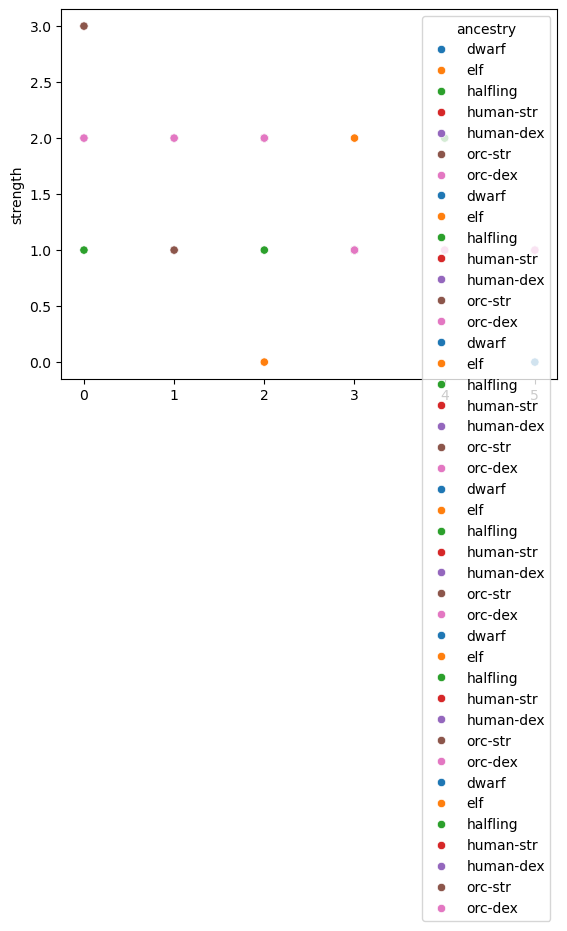

In [9]:
filter_build

for index, stat in enumerate(stat_option): 
    sns.scatterplot(data=filter_build, x=index, y=stat, hue='ancestry')

In [10]:
filter_by_class= filter_build.drop(columns=['Unnamed: 0', 'class', 'level'])
flip_for_plot= filter_by_class.T
flip_for_plot.columns= flip_for_plot.iloc[0]
flip_for_plot = flip_for_plot.drop('ancestry', axis=0)
flip_for_plot

ancestry,dwarf,elf,halfling,human-str,human-dex,orc-str,orc-dex
strength,2.0,2.0,1.0,3.0,2.0,3.0,2.0
dexterity,1.0,2.0,2.0,1.0,2.0,1.0,2.0
constitution,2.0,0.0,1.0,2.0,2.0,2.0,2.0
intelligence,1.0,2.0,1.0,1.0,1.0,1.0,1.0
wisdom,2.0,1.0,2.0,1.0,1.0,1.0,1.0
charisma,0.0,1.0,1.0,1.0,1.0,1.0,1.0


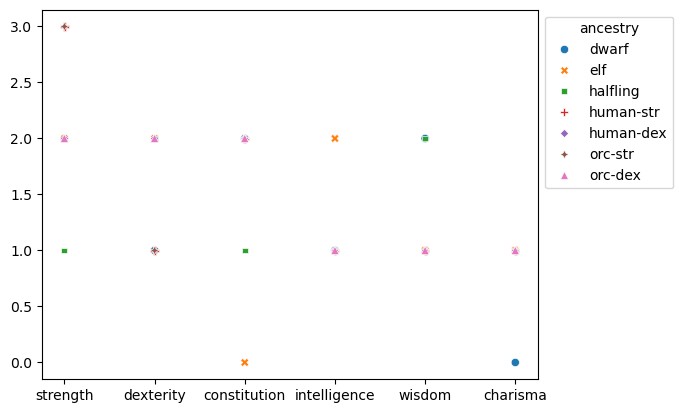

In [11]:
ax= sns.scatterplot(flip_for_plot)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

C:\Users\Mullo\AppData\Local\Temp\ipykernel_39076\2395121898.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right');


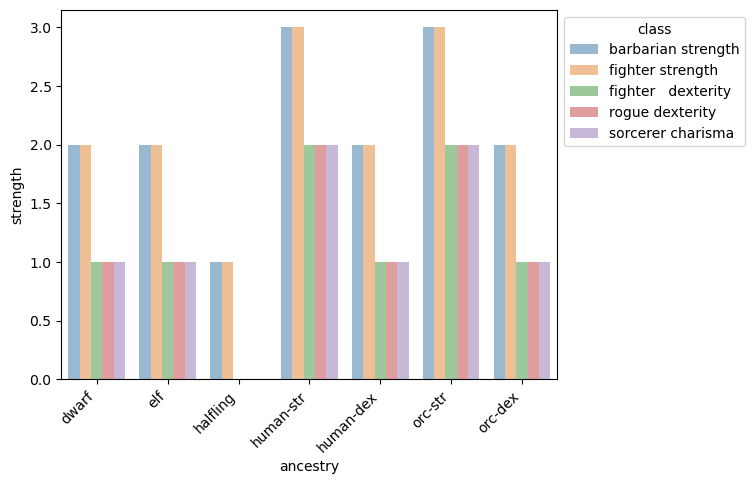

C:\Users\Mullo\AppData\Local\Temp\ipykernel_39076\2395121898.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right');


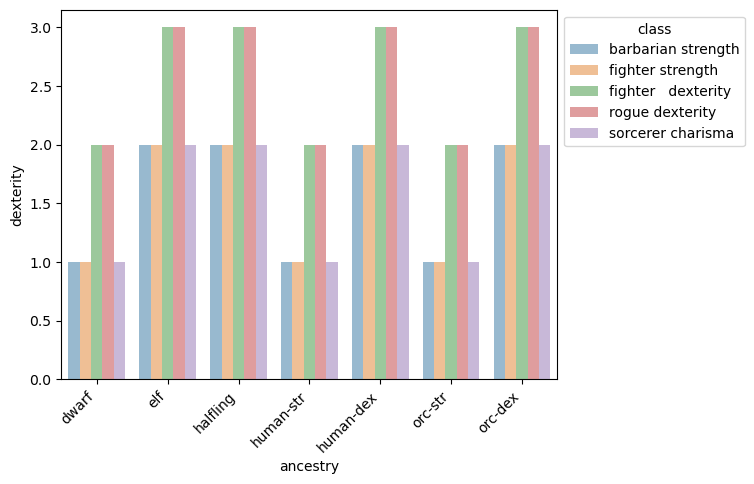

C:\Users\Mullo\AppData\Local\Temp\ipykernel_39076\2395121898.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right');


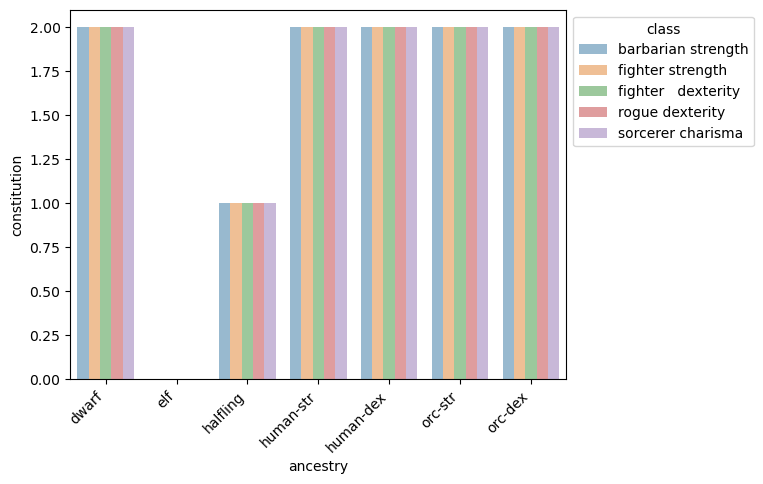

C:\Users\Mullo\AppData\Local\Temp\ipykernel_39076\2395121898.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right');


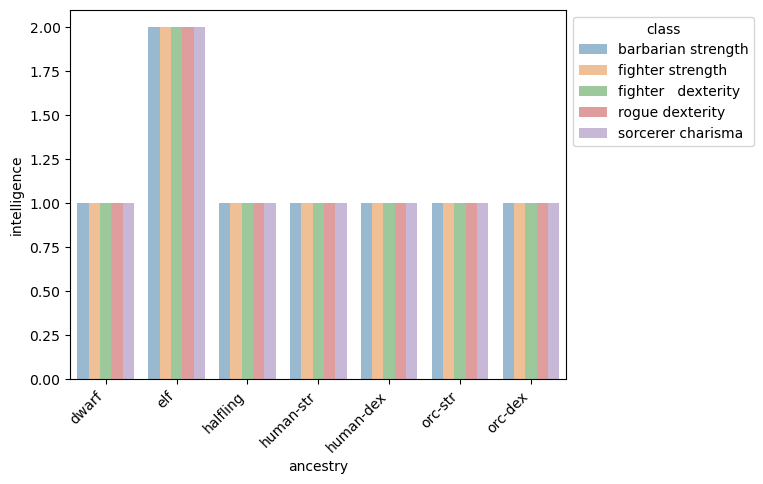

C:\Users\Mullo\AppData\Local\Temp\ipykernel_39076\2395121898.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right');


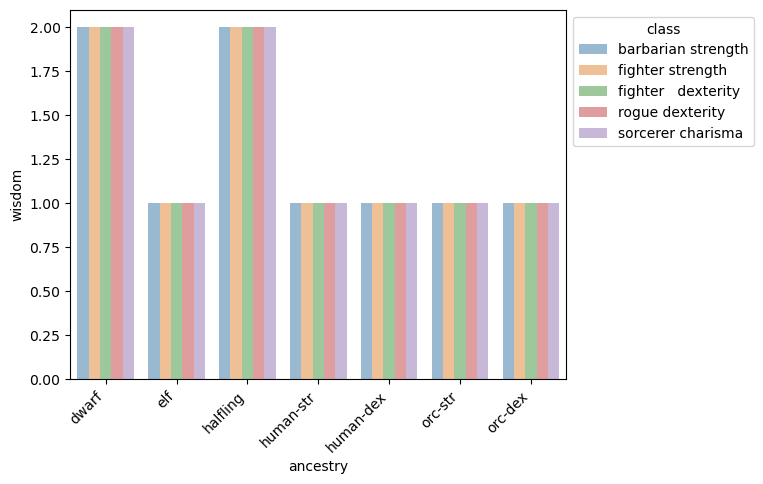

C:\Users\Mullo\AppData\Local\Temp\ipykernel_39076\2395121898.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right');


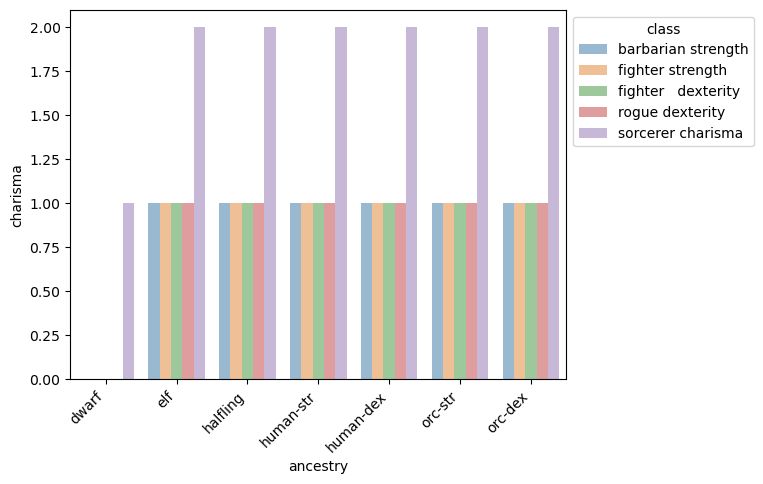

In [12]:
for stat in stat_option:
    ax = sns.barplot(x='ancestry', y=stat, hue='class', data=build_stat, alpha=0.5);
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1));
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right');
    plt.show()
    plt.close()

In [13]:
build_stat_clean = build_stat.set_index('Unnamed: 0', drop=True)

build_stat_clean[['strength', 'dexterity',
       'constitution', 'intelligence', 'wisdom', 'charisma']]

,strength,dexterity,constitution,intelligence,wisdom,charisma
Unnamed: 0,,,,,,
dwarf barbarian strength,2.0,1.0,2.0,1.0,2.0,0.0
dwarf fighter strength,2.0,1.0,2.0,1.0,2.0,0.0
dwarf fighter dexterity,1.0,2.0,2.0,1.0,2.0,0.0
dwarf rogue dexterity,1.0,2.0,2.0,1.0,2.0,0.0
dwarf sorcerer charisma,1.0,1.0,2.0,1.0,2.0,1.0
elf barbarian strength,2.0,2.0,0.0,2.0,1.0,1.0
elf fighter strength,2.0,2.0,0.0,2.0,1.0,1.0
elf fighter dexterity,1.0,3.0,0.0,2.0,1.0,1.0
elf rogue dexterity,1.0,3.0,0.0,2.0,1.0,1.0


-----------

### Simulate the average damage per round for each character build